# Melbourne Housing Market: Price Prediction Pipeline
This notebook contains data cleansing, exploratory analysis, and predictive modeling for Melbourne real estate.

In [1]:
import pandas as pd
import numpy as np

## 1. Data Loading and Initial Inspection

In [2]:
df = pd.read_csv('Melbourne_housing_FULL.csv')

In [3]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  object 
 6   SellerG        34857 non-null  object 
 7   Date           34857 non-null  object 
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  object 
 17  Lattitude      26881 non-null  float64
 18  Longti

In [5]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

In [6]:
df = df.dropna(subset=['Price'])

In [7]:
df.shape

(27247, 21)

## 2. Data Cleansing & Outlier Filtering

In [8]:
df['Landsize'].describe()

count     17982.000000
mean        593.488933
std        3757.266429
min           0.000000
25%         219.000000
50%         512.000000
75%         664.000000
max      433014.000000
Name: Landsize, dtype: float64

In [9]:
df[df['Landsize']==0]['Type'].value_counts()

u    1632
h     171
t     139
Name: Type, dtype: int64

In [10]:
df['Landsize'].quantile([0.99, 0.995])

0.990    2880.33
0.995    4668.76
Name: Landsize, dtype: float64

In [11]:
df = df[(df['Landsize']<=5000)|(df['Landsize'].isna())]

In [12]:
df.loc[(df['Type'].isin(['h', 't']))&(df['Landsize']==0), 'Landsize']=np.nan

In [13]:
df['Landsize'].describe()

count    17590.000000
mean       499.506367
std        419.503448
min          0.000000
25%        230.000000
50%        520.000000
75%        664.000000
max       4977.000000
Name: Landsize, dtype: float64

## 3. Advanced Imputation (Handling Missing Values)

In [14]:
df['Landsize']=df['Landsize'].fillna(df.groupby(['Suburb', 'Type'])['Landsize'].transform('median'))

In [15]:
df['Landsize'].isna().sum()

232

In [16]:
df['Landsize']=df['Landsize'].fillna(df['Landsize'].median())

In [17]:
df['Landsize'].isna().sum()

0

In [18]:
df['BuildingArea'].describe()

count    10613.000000
mean       152.826939
std        130.986401
min          0.000000
25%        100.000000
50%        133.000000
75%        182.000000
max       6791.000000
Name: BuildingArea, dtype: float64

In [19]:
df['BuildingArea'].quantile([0.99, 0.995])

0.990    465.0
0.995    594.0
Name: BuildingArea, dtype: float64

In [20]:
df.loc[(df['BuildingArea']<10)|(df['BuildingArea']>600), 'BuildingArea']=np.nan

In [21]:
df['BuildingArea'].describe()

count    10436.000000
mean       149.967753
std         75.271458
min         10.000000
25%        101.000000
50%        133.000000
75%        181.000000
max        594.000000
Name: BuildingArea, dtype: float64

In [22]:
df['BuildingArea'] = df['BuildingArea'].fillna(df.groupby(['Suburb', 'Rooms'])['BuildingArea'].transform('median'))

In [23]:
df['BuildingArea'].isna().sum()

500

In [24]:
df['BuildingArea'] = df['BuildingArea'].fillna(df.groupby('Rooms')['BuildingArea'].transform('median'))

In [25]:
df['BuildingArea'].isna().sum()

2

In [26]:
df['BuildingArea']=df['BuildingArea'].fillna(df['BuildingArea'].median())

In [27]:
df['BuildingArea'].isna().sum()

0

In [28]:
df['BuildingArea'].describe()

count    27165.000000
mean       140.135515
std         63.963424
min         10.000000
25%         95.000000
50%        129.000000
75%        168.000000
max        594.000000
Name: BuildingArea, dtype: float64

In [29]:
df['Month_Year']=df['Date'].dt.to_period('M')

In [30]:
df.groupby('Month_Year')['Price'].median()

Month_Year
2016-01    1009000.0
2016-02     890000.0
2016-04     837500.0
2016-05     860000.0
2016-06     850000.0
2016-07     830000.0
2016-08     870000.0
2016-09     915000.0
2016-10     904000.0
2016-11     906500.0
2016-12     950000.0
2017-02     950000.0
2017-03     941000.0
2017-04     904000.0
2017-05     940000.0
2017-06     900000.0
2017-07     750000.0
2017-08     917000.0
2017-09     890000.0
2017-10     877834.0
2017-11     860540.0
2017-12     825500.0
2018-01     785000.0
2018-02     820000.0
2018-03     880000.0
Freq: M, Name: Price, dtype: float64

In [31]:
all_types = df.groupby(['Month_Year', 'Type'])['Price'].median().reset_index()

In [32]:
df.groupby(['Month_Year', 'Type'])['Price'].count().unstack()

Type,h,t,u
Month_Year,,,
2016-01,1.0,NaN,1.0
2016-02,20.0,7.0,8.0
2016-04,272.0,44.0,84.0
2016-05,729.0,137.0,298.0
2016-06,603.0,101.0,257.0
2016-07,333.0,66.0,153.0
2016-08,559.0,96.0,255.0
2016-09,735.0,133.0,296.0
2016-10,446.0,67.0,163.0


## 4. Exploratory Data Analysis & Visualizations

In [33]:
df['Price_per_sq']=df['Price']/df['Landsize']

In [34]:
df['Distance']=df['Distance'].round()

In [35]:
df[df['Type']=='h'].groupby('Distance')['Price_per_sq'].median()

Distance
1.0     9542.599360
2.0     8888.888889
3.0     8285.714286
4.0     6609.302326
5.0     4530.605441
6.0     3340.988268
7.0     3180.778032
8.0     2729.560159
9.0     1998.201439
10.0    2000.000000
11.0    1920.000000
12.0    1623.931624
13.0    1379.975956
14.0    1717.032967
15.0    1348.693260
16.0    1245.033113
17.0    1718.193617
18.0    1134.553990
19.0    1349.693252
20.0    1229.357798
21.0    1171.974384
22.0    1592.247606
23.0    1068.345324
24.0    1337.931034
25.0    1102.841678
26.0    1318.943136
27.0    1242.482289
28.0     956.651719
29.0     800.847458
30.0     666.666667
31.0    1475.836431
32.0     737.513725
33.0     963.816418
34.0     919.661734
35.0    1016.833030
36.0     486.111111
37.0     793.131643
38.0    1004.884005
39.0     744.444444
40.0     697.866149
41.0     867.579909
43.0    1229.166667
44.0     638.528139
45.0     950.276243
46.0     539.877301
47.0     738.461538
48.0     773.529412
Name: Price_per_sq, dtype: float64

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
h_only = df[df['Type']=='h'].groupby('Distance')['Price_per_sq'].median().reset_index()

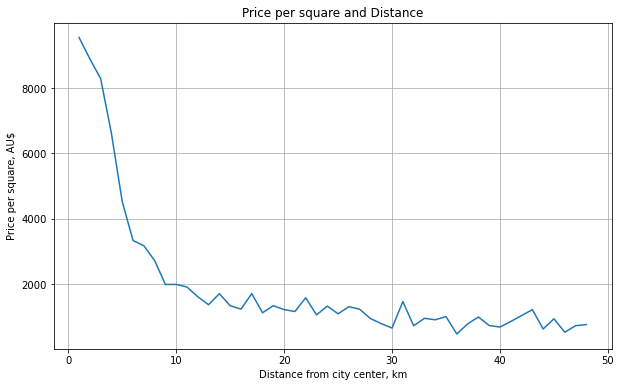

In [38]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=h_only, x='Distance', y='Price_per_sq')
plt.grid(True)
plt.title('Price per square and Distance')
plt.xlabel('Distance from city center, km')
plt.ylabel('Price per square, AU$')
plt.show()

In [39]:
all_types['Month_Year']=all_types['Month_Year'].astype(str)

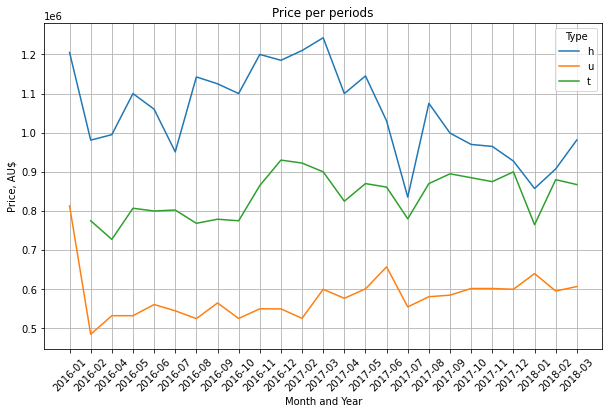

In [40]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=all_types, x='Month_Year', y='Price', hue='Type')
plt.grid(True)
plt.xticks(rotation=45)
plt.title('Price per periods')
plt.xlabel('Month and Year')
plt.ylabel('Price, AU$')
plt.show()

In [41]:
df_clean = df.dropna(subset = ['Rooms', 'Distance', 'BuildingArea'])

In [42]:
X = df_clean[['Rooms', 'Distance', 'BuildingArea']]
y = df_clean['Price']

In [43]:
X.shape, y.shape

((27164, 3), (27164,))

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
model = LinearRegression()

In [48]:
model.fit(X_train, y_train)

LinearRegression()

In [49]:
y_pred = model.predict(X_test)

In [50]:
print(model.coef_)

[130816.88121343 -34540.63340199   4704.17639397]


In [51]:
from sklearn.metrics import mean_absolute_error, r2_score

In [52]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 331236.55331405
R2: 0.43423670249787705


## 5. Feature Engineering & Categorical Encoding

In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
df_ml = df.dropna(subset=['Rooms', 'Distance', 'BuildingArea', 'Type']).copy()

df_ml['Inverse_Distance'] = 1 / (df_ml['Distance'] + 0.1)
df_ml = pd.get_dummies(df_ml, columns=['Type'], drop_first=True)

In [55]:
X = df_ml[['Rooms', 'Distance', 'Inverse_Distance', 'BuildingArea', 'Type_t', 'Type_u']]
y = df_ml['Price']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
model_v2 = LinearRegression()

In [59]:
model_v2.fit(X_train_scaled, y_train)

LinearRegression()

In [60]:
y2_pred = model_v2.predict(X_test_scaled)

In [61]:
print(model_v2.coef_)

[  58465.43217555 -244732.56975379    4553.81239025  299393.68797657
  -60340.16247585 -128626.90147055]


In [62]:
print("MAE:", mean_absolute_error(y_test, y2_pred))
print("R2:", r2_score(y_test, y2_pred))

MAE: 318274.7775427065
R2: 0.4605392060522734


In [63]:
from sklearn.ensemble import RandomForestRegressor

In [64]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [65]:
model_rf.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [66]:
y_rf_pred = model_rf.predict(X_test_scaled)

In [67]:
print("MAE:", mean_absolute_error(y_test, y_rf_pred))
print("R2:", r2_score(y_test, y_rf_pred))

MAE: 249702.25228944726
R2: 0.5862612503112703


In [68]:
df_ml = df.dropna(subset=['Rooms', 'Distance', 'BuildingArea', 'Type', 'Regionname']).copy()
df_ml['Inverse_Distance'] = 1 / (df_ml['Distance'] + 0.1)
df_ml = pd.get_dummies(df_ml, columns=['Type', 'Regionname'], drop_first=True)

In [69]:
df_ml.rename(columns={'Distance':'Ds', 'Inverse_Distance':'Inv', 'BuildingArea':'BAr', 'Type_t':'t', 'Type_u':'u', 'Regionname_Eastern Victoria':'EV', 'Regionname_Northern Metropolitan':'NM', 'Regionname_Northern Victoria':'NV', 'Regionname_South-Eastern Metropolitan':'SEM', 'Regionname_Southern Metropolitan':'SM', 'Regionname_Western Metropolitan':'WM', 'Regionname_Western Victoria':'WV'}, inplace=True)

## 6. Model Training & Evaluation (Random Forest Regressor)

In [70]:
X = df_ml[['Rooms', 'BAr', 'Ds', 'Inv', 't', 'u', 'EV', 'NM', 'NV', 'SEM', 'SM', 'WM', 'WV']]
y = df_ml['Price']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [74]:
model_rf.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [75]:
y_rf_pred = model_rf.predict(X_test_scaled)

In [76]:
print("MAE:", mean_absolute_error(y_test, y_rf_pred))
print("R2:", r2_score(y_test, y_rf_pred))

MAE: 211064.78708632808
R2: 0.6758689566303179


## 7. Feature Importance Analysis

In [77]:
imp = pd.Series(data=model_rf.feature_importances_, index=X_train.columns)

In [78]:
imp.sort_values(ascending=False).round(3)

BAr      0.469
SM       0.199
Ds       0.090
Inv      0.088
u        0.054
Rooms    0.042
t        0.023
NM       0.016
WM       0.015
SEM      0.004
EV       0.000
NV       0.000
WV       0.000
dtype: float64

In [79]:
X = X.drop(columns=['EV', 'NV', 'WV', 'SEM'])

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [83]:
model_rf.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [84]:
y_rf_pred = model_rf.predict(X_test_scaled)

In [85]:
print("MAE:", mean_absolute_error(y_test, y_rf_pred))
print("R2:", r2_score(y_test, y_rf_pred))

MAE: 211363.64231716527
R2: 0.6758670223221515


In [86]:
imp = pd.Series(data=model_rf.feature_importances_, index=X_train.columns)

In [87]:
imp.sort_values(ascending=False).round(3)

BAr      0.470
SM       0.199
Inv      0.092
Ds       0.087
u        0.054
Rooms    0.042
t        0.023
NM       0.017
WM       0.015
dtype: float64

## 8. Production-Ready Inference Function

In [90]:
def predict_house_price(rooms, distance, building_area, house_type, region):
    
    input_data = {col: 0 for col in X_train.columns}
    
    
    input_data['Rooms'] = rooms
    input_data['Ds'] = distance
    input_data['Inv'] = 1 / (distance + 0.1)
    input_data['BAr'] = building_area
    
    
    if house_type in input_data:
        input_data[house_type] = 1
        
    if region in input_data:
        input_data[region] = 1
        
    
    X_single = pd.DataFrame([input_data])
       
    X_single = X_single[X_train.columns]
        
    X_single_scaled = scaler.transform(X_single)
    predicted_price = model_rf.predict(X_single_scaled)[0]
    
    return f"{predicted_price:,.2f}"

In [91]:
print(predict_house_price(3, 5, 150, 'h', 'SM'))

1,748,268.10
